# Dataset Image Count Report

This notebook shows:
- the total number of resized images, including each resized-image folder;
- the total number of detection-dataset images;
- the train, validation, and test image counts and percentages.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

# This works whether Jupyter starts in the repository root or notebooks/.
current_dir = Path.cwd().resolve()
if (current_dir / 'detection_dataset').is_dir():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'detection_dataset').is_dir():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError('Could not find detection_dataset. Start Jupyter from the project root or notebooks folder.')

RESIZED_DIR = PROJECT_ROOT / 'resized_images'
DETECTION_IMAGES_DIR = PROJECT_ROOT / 'detection_dataset' / 'images'

def image_files(folder):
    """Return all supported image files below folder, recursively."""
    if not folder.is_dir():
        return []
    return [p for p in folder.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System


## Resized images

In [2]:
if not RESIZED_DIR.is_dir():
    raise FileNotFoundError(f'Resized-image folder not found: {RESIZED_DIR}')

resized_rows = []
for folder in sorted(p for p in RESIZED_DIR.iterdir() if p.is_dir()):
    resized_rows.append({'Folder': folder.name, 'Images': len(image_files(folder))})

resized_df = pd.DataFrame(resized_rows)
total_resized = len(image_files(RESIZED_DIR))

display(resized_df)
print(f'Total resized images: {total_resized:,}')

,Folder,Images
0,healthy,138
1,healthy01,305
2,healthy02,265
3,unhealthy,360
4,unhealthy01,90
5,unhealthy02,195


Total resized images: 1,353


## Detection dataset: train, validation, and test

In [3]:
split_names = {'train': 'Train', 'val': 'Validation', 'test': 'Test'}
split_counts = {split: len(image_files(DETECTION_IMAGES_DIR / split)) for split in split_names}
total_detection = sum(split_counts.values())

split_df = pd.DataFrame([
    {
        'Split': display_name,
        'Images': split_counts[split],
        'Percentage': (100 * split_counts[split] / total_detection) if total_detection else 0,
    }
    for split, display_name in split_names.items()
])
split_df['Percentage'] = split_df['Percentage'].map(lambda value: f'{value:.2f}%')

display(split_df)
print(f'Total detection dataset images: {total_detection:,}')

,Split,Images,Percentage
0,Train,943,69.70%
1,Validation,271,20.03%
2,Test,139,10.27%


Total detection dataset images: 1,353


## Missing labels

In [ ]:
DETECTION_LABELS_DIR = PROJECT_ROOT / 'detection_dataset' / 'labels'
missing_labels_by_split = {}

for split in split_names:
    split_image_dir = DETECTION_IMAGES_DIR / split
    split_label_dir = DETECTION_LABELS_DIR / split
    images = image_files(split_image_dir)
    missing_labels_by_split[split] = [
        image.relative_to(split_image_dir).as_posix()
        for image in images
        if not (split_label_dir / image.relative_to(split_image_dir)).with_suffix('.txt').is_file()
    ]

missing_label_df = pd.DataFrame([
    {
        'Split': split_names[split],
        'Images': split_counts[split],
        'Missing labels': len(missing_labels_by_split[split]),
    }
    for split in split_names
])
display(missing_label_df)

total_missing_labels = sum(len(files) for files in missing_labels_by_split.values())
print(f'Total images missing labels: {total_missing_labels:,}')

for split, files in missing_labels_by_split.items():
    print(f'\n{split_names[split]} missing labels ({len(files)}):')
    if files:
        for filename in files:
            print(f'  - {filename}')
    else:
        print('  None')

## Summary

,Metric,Images
0,Total resized images,1353
1,Total detection images,1353
2,Train,943
3,Validation,271
4,Test,139


Check: resized and detection image totals match.


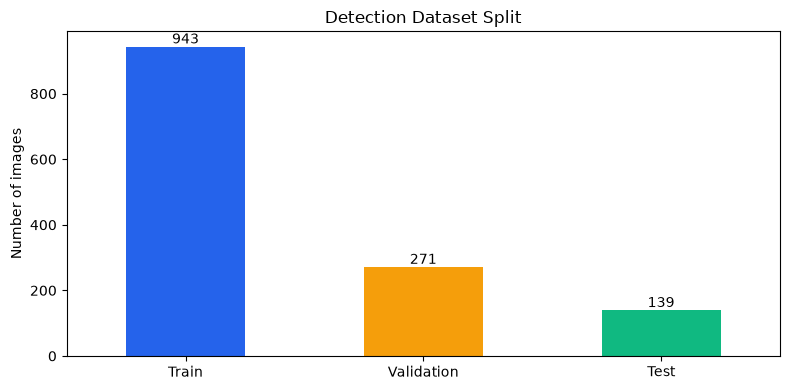

In [4]:
summary_df = pd.DataFrame({
    'Metric': ['Total resized images', 'Total detection images', 'Train', 'Validation', 'Test'],
    'Images': [total_resized, total_detection, split_counts['train'], split_counts['val'], split_counts['test']],
})
display(summary_df)

difference = total_resized - total_detection
if difference == 0:
    print('Check: resized and detection image totals match.')
else:
    print(f'Check: totals differ by {abs(difference):,} image(s).')

ax = pd.Series(split_counts).rename(index=split_names).plot(
    kind='bar', color=['#2563eb', '#f59e0b', '#10b981'], figsize=(8, 4)
)
ax.set_title('Detection Dataset Split')
ax.set_xlabel('')
ax.set_ylabel('Number of images')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
from pathlib import Path
import pandas as pd

# Run from the project root or the notebooks folder
current_dir = Path.cwd().resolve()

if (current_dir / "detection_dataset").is_dir():
    project_root = current_dir
elif (current_dir.parent / "detection_dataset").is_dir():
    project_root = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find detection_dataset. "
        "Run this code from the project root or notebooks folder."
    )

images_root = project_root / "detection_dataset" / "images"
labels_root = project_root / "detection_dataset" / "labels"

splits = {
    "train": "Train",
    "val": "Validation",
    "test": "Test",
}

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}

missing_labels_by_split = {}
report_rows = []

for split, display_name in splits.items():
    image_dir = images_root / split
    label_dir = labels_root / split

    if not image_dir.is_dir():
        print(f"Warning: image directory not found: {image_dir}")
        images = []
    else:
        images = sorted(
            path
            for path in image_dir.rglob("*")
            if path.is_file()
            and path.suffix.lower() in image_extensions
        )

    missing_labels = []

    for image_path in images:
        relative_image_path = image_path.relative_to(image_dir)

        # Example:
        # healthy_001.jpg -> healthy_001.txt
        expected_label_path = (
            label_dir / relative_image_path
        ).with_suffix(".txt")

        if not expected_label_path.is_file():
            missing_labels.append(relative_image_path.as_posix())

    missing_labels_by_split[split] = missing_labels

    report_rows.append(
        {
            "Split": display_name,
            "Total images": len(images),
            "Missing labels": len(missing_labels),
        }
    )

# Display summary
report_df = pd.DataFrame(report_rows)
display(report_df)

total_missing = sum(
    len(files) for files in missing_labels_by_split.values()
)

print(f"\nTotal images missing labels: {total_missing}")

# Print filenames
for split, display_name in splits.items():
    files = missing_labels_by_split[split]

    print(f"\n{display_name} missing labels ({len(files)}):")

    if files:
        for filename in files:
            print(f"  - {filename}")
    else:
        print("  None")


,Split,Total images,Missing labels
0,Train,943,321
1,Validation,271,92
2,Test,139,47



Total images missing labels: 460

Train missing labels (321):
  - healthy_0444.jpg
  - healthy_0446.jpg
  - healthy_0447.jpg
  - healthy_0448.jpg
  - healthy_0449.jpg
  - healthy_0452.jpg
  - healthy_0453.jpg
  - healthy_0454.jpg
  - healthy_0457.jpg
  - healthy_0458.jpg
  - healthy_0459.jpg
  - healthy_0462.jpg
  - healthy_0463.jpg
  - healthy_0465.jpg
  - healthy_0466.jpg
  - healthy_0471.jpg
  - healthy_0472.jpg
  - healthy_0473.jpg
  - healthy_0474.jpg
  - healthy_0476.jpg
  - healthy_0477.jpg
  - healthy_0478.jpg
  - healthy_0479.jpg
  - healthy_0480.jpg
  - healthy_0481.jpg
  - healthy_0482.jpg
  - healthy_0485.jpg
  - healthy_0486.jpg
  - healthy_0487.jpg
  - healthy_0489.jpg
  - healthy_0490.jpg
  - healthy_0491.jpg
  - healthy_0492.jpg
  - healthy_0495.jpg
  - healthy_0497.jpg
  - healthy_0498.jpg
  - healthy_0504.jpg
  - healthy_0505.jpg
  - healthy_0506.jpg
  - healthy_0507.jpg
  - healthy_0508.jpg
  - healthy_0509.jpg
  - healthy_0510.jpg
  - healthy_0512.jpg
  - healthy_0